# P-VAE revisit

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

model_type = 'poisson'

## indicator_approx = `cubic`

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'lin|lin')

cfg_vae['indicator_approx'] = 'cubic'

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_ch': 32, 'n_latents': 512, 'prior_clamp': -4, 'fit_prior': True, 'enc_type': 'lin', 
'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'init_dist': 'Normal', 'init_scale': 0.05, 
'indicator_approx': 'cubic'}

Trainer:
{'lr': 0.005, 'batch_size': 1000, 'epochs': 3000, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 500, 
'kl_const_portion': 0.0}

poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>
mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,20:06)

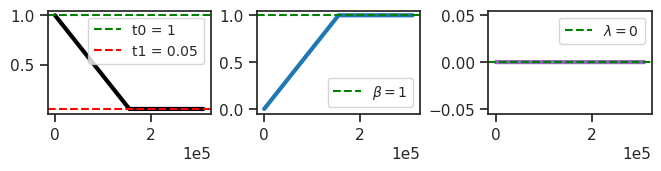

In [4]:
vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.show_schedules()

In [5]:
print(vae)

PoissonVAE(
  (mse): MSELoss()
  (fc_enc): Linear(in_features=256, out_features=512, bias=False)
  (fc_dec): Linear(in_features=512, out_features=256, bias=False)
)

### print cfg

In [6]:
print(f"vae.cfg:\n\n{vars(vae.cfg)}\n\n\ntr.cfg:\n\n{vars(tr.cfg)}")

vae.cfg:

{'indicator_approx': 'cubic', 'prior_log_dist': 'uniform', 'prior_clamp': -4, 'hard_fwd': False, 'exc_only': False,
'enc_type': 'lin', 'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'enc_norm': False, 'dec_norm': False, 
'dataset': 'vH16', 'input_sz': 16, 'n_ch': 32, 'n_latents': 512, 'fit_prior': True, 'use_bn': False, 'use_se': 
True, 'res_eps': 1.0, 'init_dist': 'Normal', 'init_scale': 0.05, 'activation_fn': 'swish', 'seed': 0, 'base_dir': 
'/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


tr.cfg:

{'lr': 0.005, 'epochs': 3000, 'batch_size': 1000, 'warm_restart': 0, 'warmup_epochs': 5, 'optimizer': 
'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 'scheduler_type': 
'cosine', 'scheduler_kws': {'T_max': 2995.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 500, 'chkpt_freq': 
50, 'eval_freq': 20, 'log_freq': 10, 'use_amp': False, 'method': 'mc', 'kl_beta': 1.0, 'kl_beta_min': 0.0001, 
'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.5, 'kl_const_portion': 0.0, 'lambda_anneal': False, 'lambda_init': 
0.0, 'lambda_norm': 0.0, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

### train

In [7]:
comment = f"indicator={vae.cfg.indicator_approx}_{tr.cfg.name()}"
print(comment)

indicator=cubic_mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)

In [8]:
# comment = tr.cfg.name()
tr.train(fit_name=comment)

epoch # 3000, avg loss: 166.501682: 100%|█| 3000/3000 [3:37:00<00:00,  4.34s/it]


### vld

In [9]:
data, loss, rates = tr.validate()

_loss = {k: v.mean() for k, v in loss.items()}
_loss['tot'] = _loss['mse'] + _loss['kl']
print(_loss)

{'r2': 0.25983512, 'mse': 137.63449, 'kl': 31.10637, 'kl_diag': 0.06075277, 'tot': 168.74086}

In [7]:
## was: sigmoid

{'r2': 0.2626517, 'mse': 137.21419, 'kl': 32.404213, 'kl_diag': 0.06328392, 'tot': 169.61841}

In [10]:
lifetime, population, percents = sparse_score(data['z'], cutoff=0.05)
print(percents)

{'0': 77.6, '1': 17.1, '2': 3.8, '3+': 1.5}

In [9]:
## was: sigmoid

{'0': 73.6, '1': 18.9, '2': 4.9, '3+': 2.5}

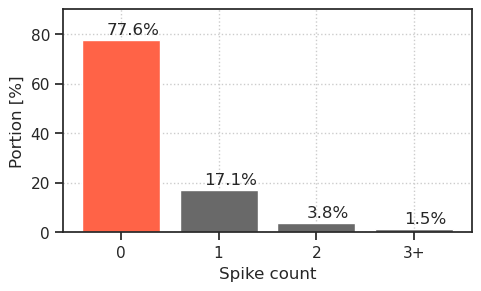

In [11]:
fig, ax = create_figure(1, 1, (4.7, 2.8))

max_val = float(list(percents.values())[0])
ax.set(
    xlabel='Spike count',
    ylabel='Portion [%]',
    ylim=(0, (np.ceil(max_val / 10) + 1) * 10),
)
colors = ['tomato' if lbl == '0' else 'dimgrey' for lbl in percents]
bars = ax.bar(percents.keys(), percents.values(), color=colors)

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + 1.3 * bar.get_width() / 2
    plt.text(x, y + 1, f'{y:0.1f}%', ha='center', va='bottom')

ax.locator_params(axis='y', nbins=5)

ax.grid()
plt.show()

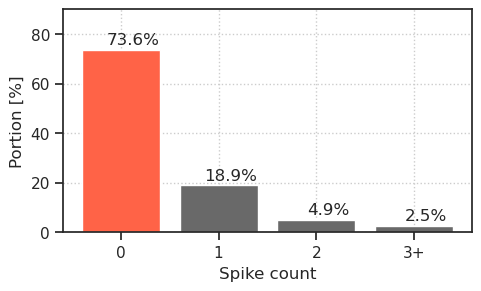

In [10]:
## was: sigmoid

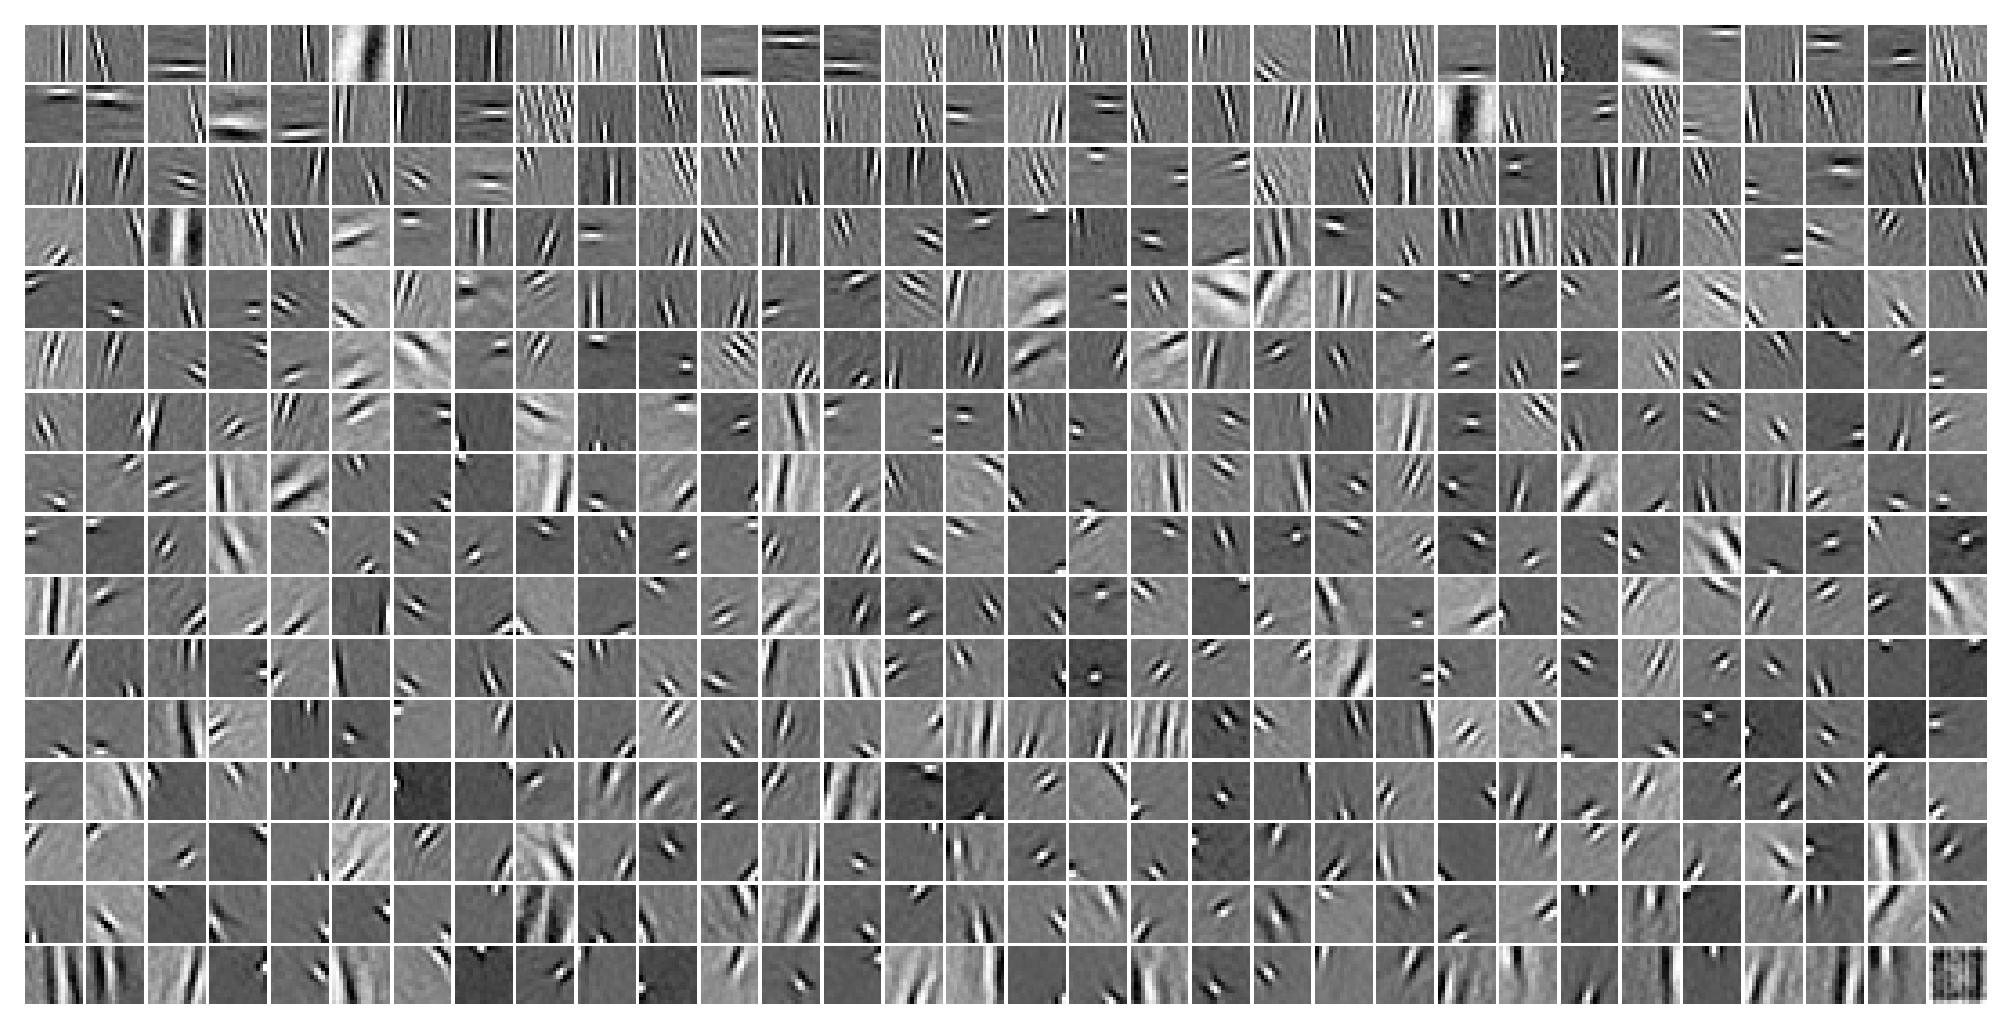

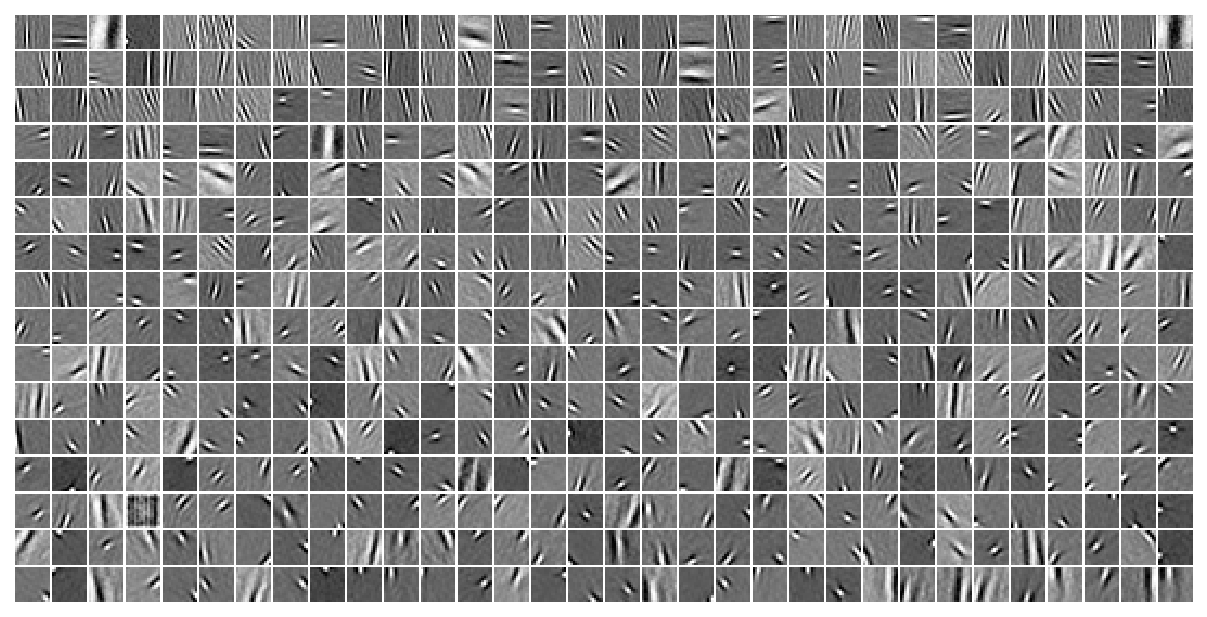

In [13]:
vae.show(dpi=250, order=np.argsort(tonp(vae.log_rate.squeeze())));
vae.show(dpi=150, order=np.argsort(loss['kl_diag']));

## indicator_approx = `linear`

poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>
mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,09:16)

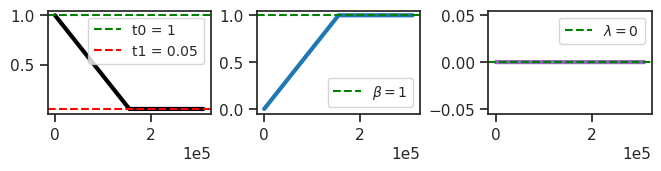

PoissonVAE(
  (mse): MSELoss()
  (fc_enc): Linear(in_features=256, out_features=512, bias=False)
  (fc_dec): Linear(in_features=512, out_features=256, bias=False)
)

vae.cfg:

{'indicator_approx': 'linear', 'prior_log_dist': 'uniform', 'prior_clamp': -4, 'hard_fwd': False, 'exc_only': 
False, 'enc_type': 'lin', 'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'enc_norm': False, 'dec_norm': 
False, 'dataset': 'vH16', 'input_sz': 16, 'n_ch': 32, 'n_latents': 512, 'fit_prior': True, 'use_bn': False, 
'use_se': True, 'res_eps': 1.0, 'init_dist': 'Normal', 'init_scale': 0.05, 'activation_fn': 'swish', 'seed': 0, 
'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


tr.cfg:

{'lr': 0.005, 'epochs': 3000, 'batch_size': 1000, 'warm_restart': 0, 'warmup_epochs': 5, 'optimizer': 
'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 'scheduler_type': 
'cosine', 'scheduler_kws': {'T_max': 2995.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 500, 'chkpt_freq': 
50, 'eval_freq': 20, 'log_freq': 10, 'use_amp': False, 'method': 'mc', 'kl_beta': 1.0, 'kl_beta_min': 0.0001, 
'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.5, 'kl_const_portion': 0.0, 'lambda_anneal': False, 'lambda_init': 
0.0, 'lambda_norm': 0.0, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'lin|lin')

cfg_vae['indicator_approx'] = 'linear'

vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.show_schedules()

print(vae)

print(f"vae.cfg:\n\n{vars(vae.cfg)}\n\n\ntr.cfg:\n\n{vars(tr.cfg)}")

### train

In [4]:
comment = f"indicator={vae.cfg.indicator_approx}_{tr.cfg.name()}"
print(comment)

indicator=linear_mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)

In [5]:
# comment = tr.cfg.name()
tr.train(fit_name=comment)

epoch # 3000, avg loss: 166.232528: 100%|█| 3000/3000 [2:26:54<00:00,  2.94s/it]


### vld

In [6]:
data, loss, rates = tr.validate()

_loss = {k: v.mean() for k, v in loss.items()}
_loss['tot'] = _loss['mse'] + _loss['kl']
print(_loss)

{'r2': 0.25151125, 'mse': 139.74873, 'kl': 31.390203, 'kl_diag': 0.061305337, 'tot': 171.13893}

In [9]:
## was: cubic

{'r2': 0.25983512, 'mse': 137.63449, 'kl': 31.10637, 'kl_diag': 0.06075277, 'tot': 168.74086}

In [7]:
## was: sigmoid

{'r2': 0.2626517, 'mse': 137.21419, 'kl': 32.404213, 'kl_diag': 0.06328392, 'tot': 169.61841}

In [7]:
lifetime, population, percents = sparse_score(data['z'], cutoff=0.05)
print(percents)

{'0': 76.9, '1': 17.1, '2': 4.1, '3+': 1.9}

In [10]:
## Was: cubic

{'0': 77.6, '1': 17.1, '2': 3.8, '3+': 1.5}

In [9]:
## was: sigmoid

{'0': 73.6, '1': 18.9, '2': 4.9, '3+': 2.5}

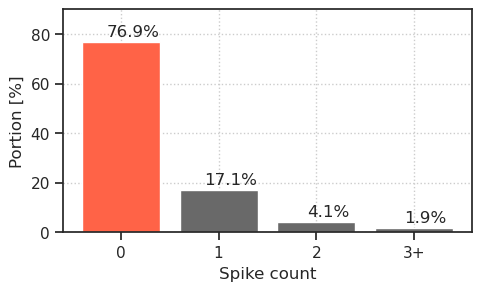

In [8]:
fig, ax = create_figure(1, 1, (4.7, 2.8))

max_val = float(list(percents.values())[0])
ax.set(
    xlabel='Spike count',
    ylabel='Portion [%]',
    ylim=(0, (np.ceil(max_val / 10) + 1) * 10),
)
colors = ['tomato' if lbl == '0' else 'dimgrey' for lbl in percents]
bars = ax.bar(percents.keys(), percents.values(), color=colors)

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + 1.3 * bar.get_width() / 2
    plt.text(x, y + 1, f'{y:0.1f}%', ha='center', va='bottom')

ax.locator_params(axis='y', nbins=5)

ax.grid()
plt.show()

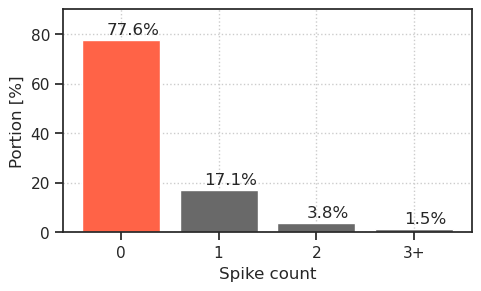

In [11]:
## was: cubic

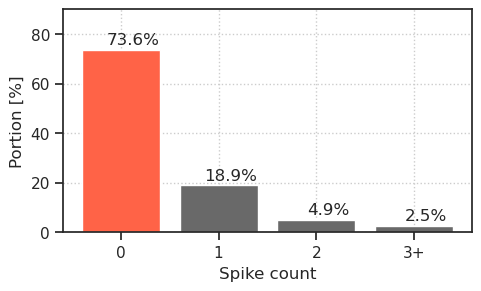

In [10]:
## was: sigmoid

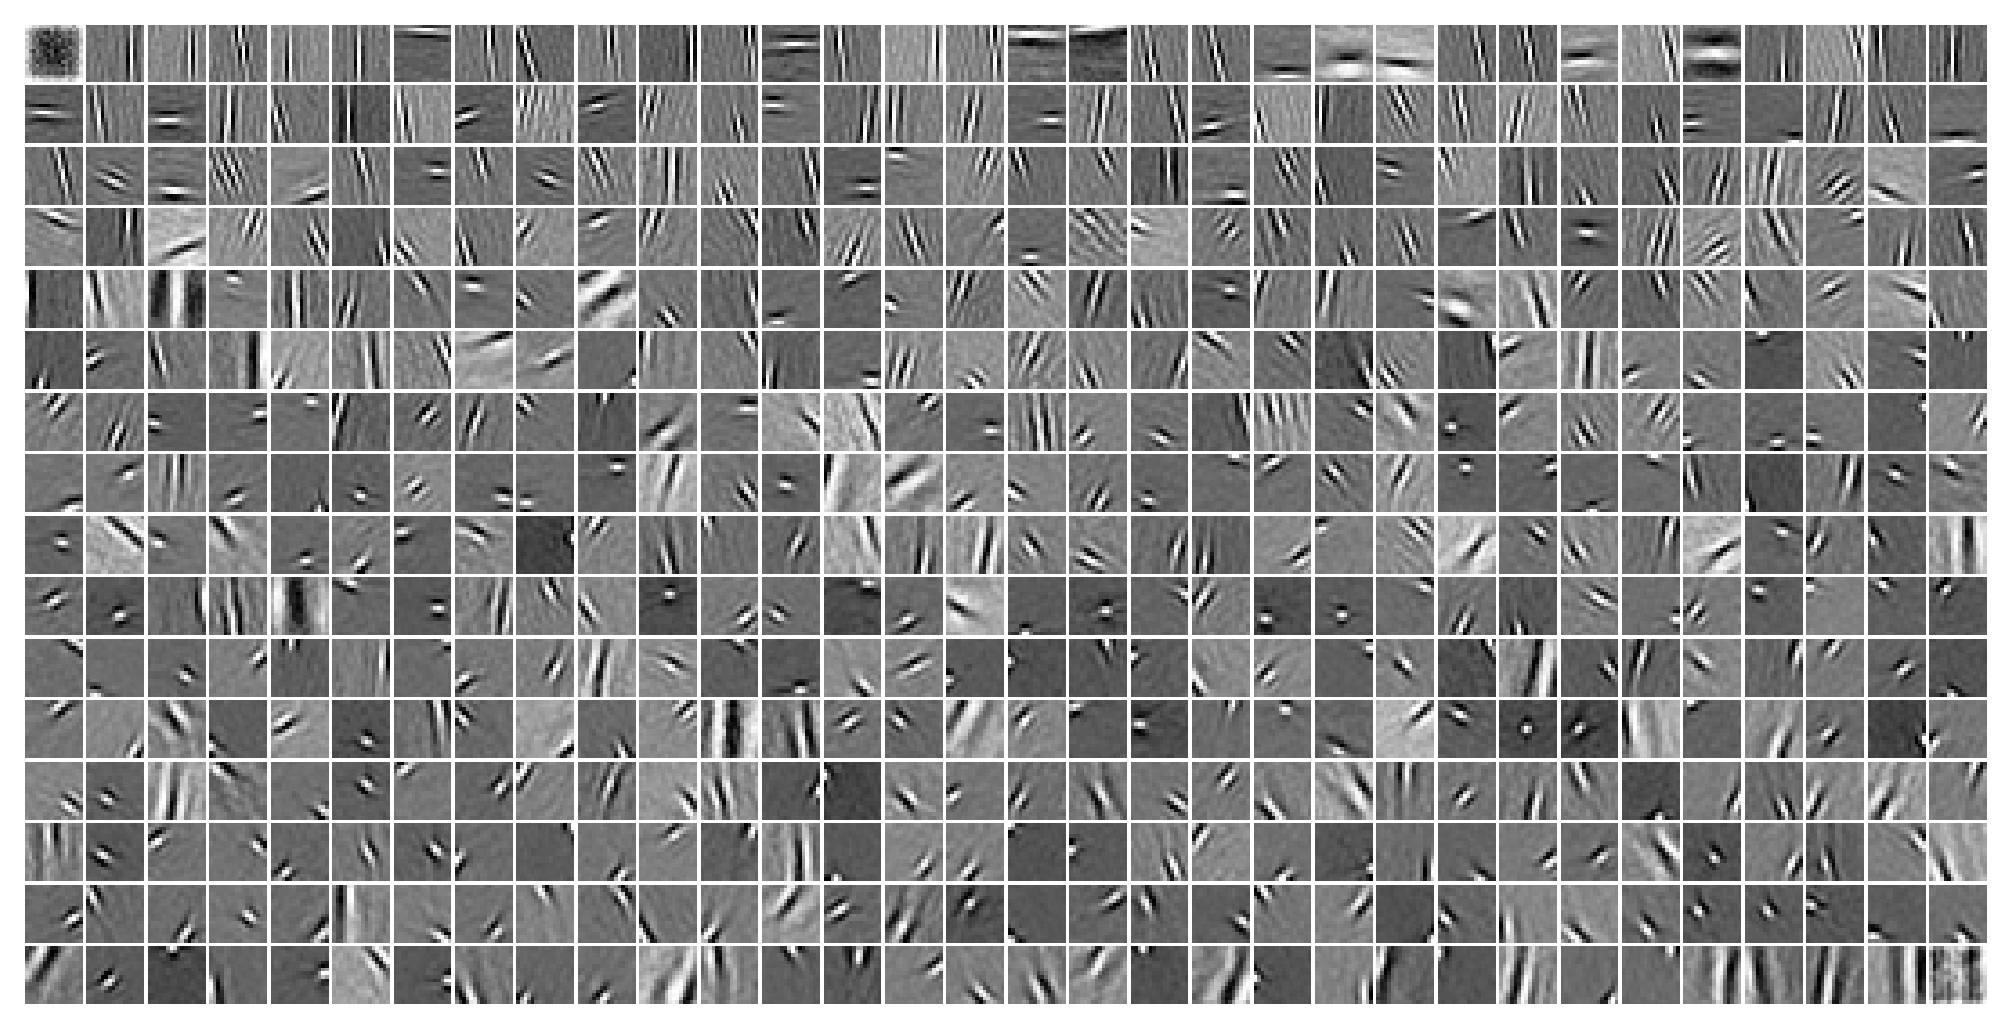

In [9]:
vae.show(dpi=250, order=np.argsort(tonp(vae.log_rate.squeeze())));

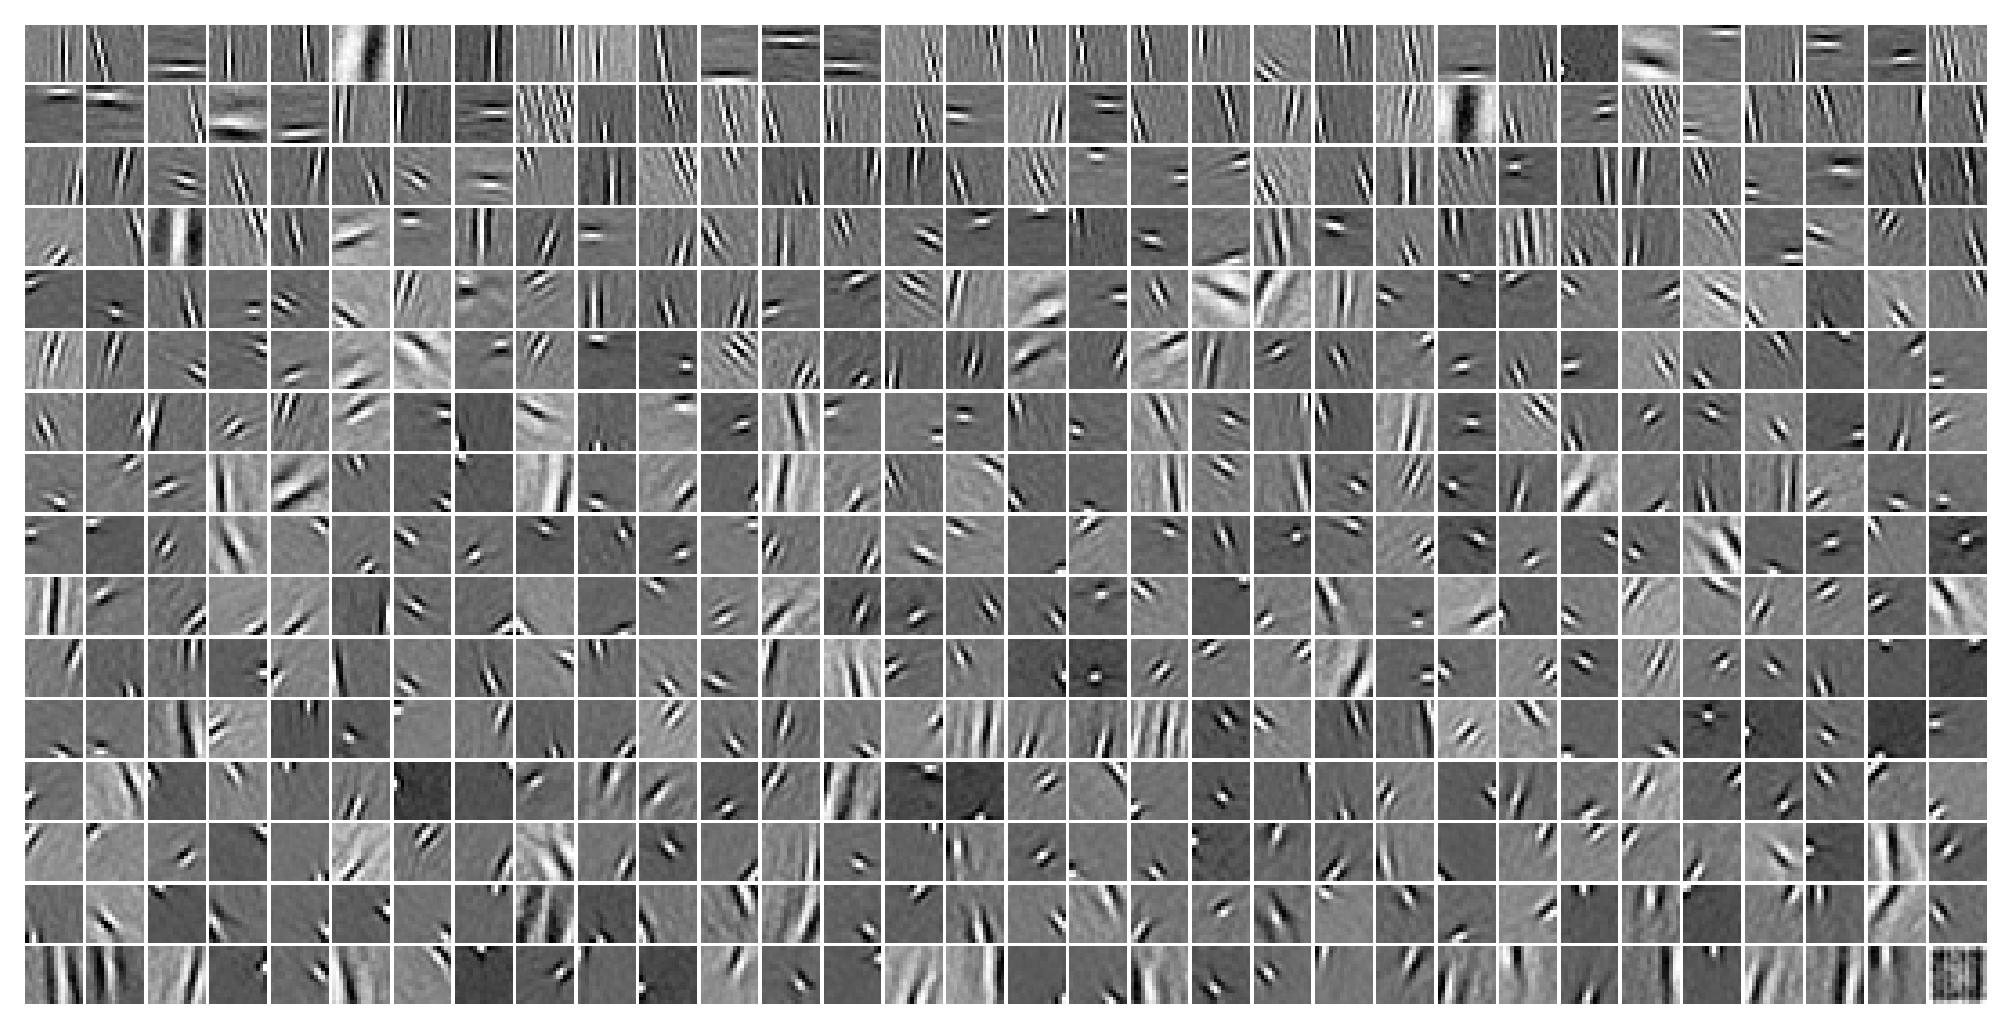

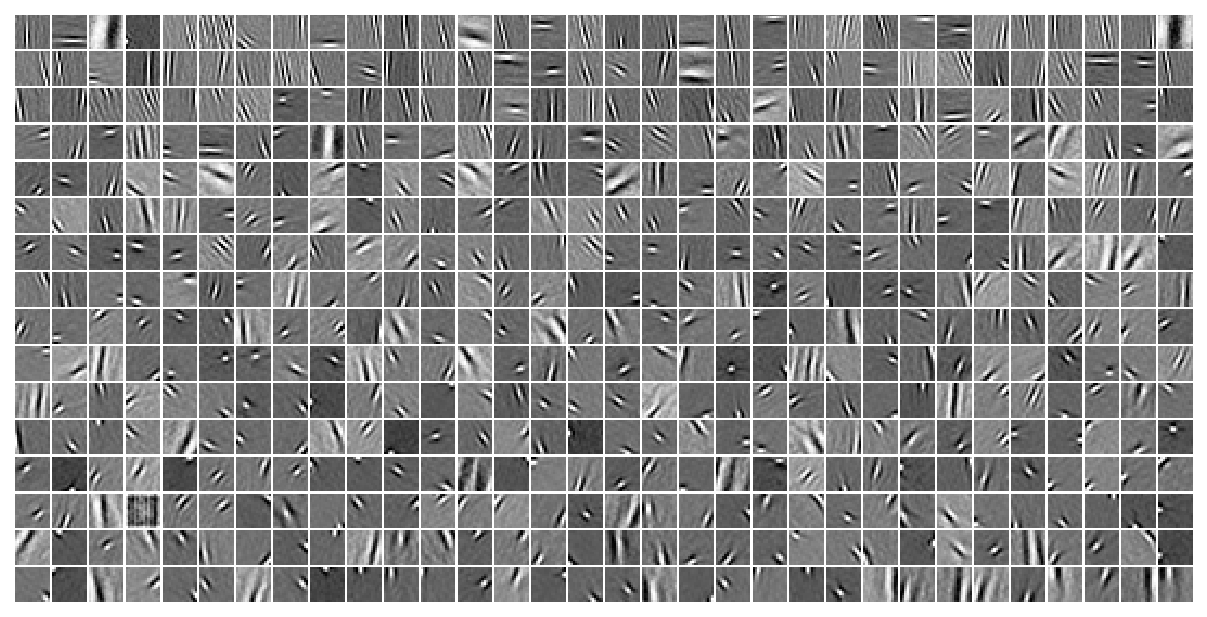

In [13]:
## was: cubic

## indicator_approx = `cosine`

poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>
mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,11:43)

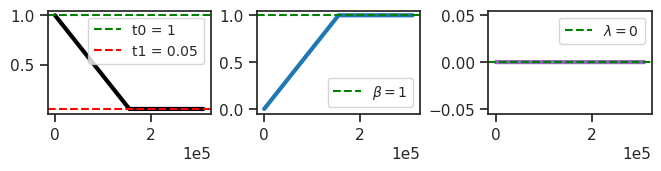

PoissonVAE(
  (mse): MSELoss()
  (fc_enc): Linear(in_features=256, out_features=512, bias=False)
  (fc_dec): Linear(in_features=512, out_features=256, bias=False)
)

vae.cfg:

{'indicator_approx': 'cosine', 'prior_log_dist': 'uniform', 'prior_clamp': -4, 'hard_fwd': False, 'exc_only': 
False, 'enc_type': 'lin', 'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'enc_norm': False, 'dec_norm': 
False, 'dataset': 'vH16', 'input_sz': 16, 'n_ch': 32, 'n_latents': 512, 'fit_prior': True, 'use_bn': False, 
'use_se': True, 'res_eps': 1.0, 'init_dist': 'Normal', 'init_scale': 0.05, 'activation_fn': 'swish', 'seed': 0, 
'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_fp_nrm-none_<lin|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


tr.cfg:

{'lr': 0.005, 'epochs': 3000, 'batch_size': 1000, 'warm_restart': 0, 'warmup_epochs': 5, 'optimizer': 
'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 'scheduler_type': 
'cosine', 'scheduler_kws': {'T_max': 2995.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 500, 'chkpt_freq': 
50, 'eval_freq': 20, 'log_freq': 10, 'use_amp': False, 'method': 'mc', 'kl_beta': 1.0, 'kl_beta_min': 0.0001, 
'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.5, 'kl_const_portion': 0.0, 'lambda_anneal': False, 'lambda_init': 
0.0, 'lambda_norm': 0.0, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [10]:
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'lin|lin')

cfg_vae['indicator_approx'] = 'cosine'

vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.show_schedules()

print(vae)

print(f"vae.cfg:\n\n{vars(vae.cfg)}\n\n\ntr.cfg:\n\n{vars(tr.cfg)}")

### train

In [11]:
comment = f"indicator={vae.cfg.indicator_approx}_{tr.cfg.name()}"
print(comment)

indicator=cosine_mc_b1000-ep3000-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)

In [12]:
# comment = tr.cfg.name()
tr.train(fit_name=comment)

epoch # 3000, avg loss: 166.540660: 100%|█| 3000/3000 [2:56:44<00:00,  3.53s/it]


### vld

In [13]:
data, loss, rates = tr.validate()

_loss = {k: v.mean() for k, v in loss.items()}
_loss['tot'] = _loss['mse'] + _loss['kl']
print(_loss)

{'r2': 0.2538663, 'mse': 139.15414, 'kl': 31.164661, 'kl_diag': 0.060864903, 'tot': 170.3188}

In [9]:
## was: cubic

{'r2': 0.25983512, 'mse': 137.63449, 'kl': 31.10637, 'kl_diag': 0.06075277, 'tot': 168.74086}

In [7]:
## was: sigmoid

{'r2': 0.2626517, 'mse': 137.21419, 'kl': 32.404213, 'kl_diag': 0.06328392, 'tot': 169.61841}

In [14]:
lifetime, population, percents = sparse_score(data['z'], cutoff=0.05)
print(percents)

{'0': 77.4, '1': 16.8, '2': 3.9, '3+': 1.9}

In [10]:
## Was: cubic

{'0': 77.6, '1': 17.1, '2': 3.8, '3+': 1.5}

In [9]:
## was: sigmoid

{'0': 73.6, '1': 18.9, '2': 4.9, '3+': 2.5}

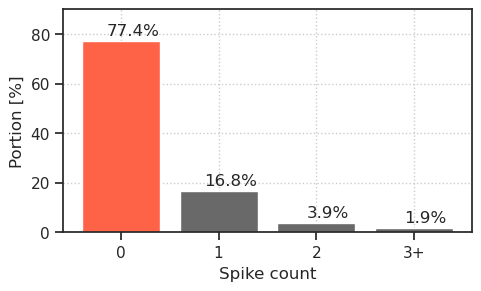

In [15]:
fig, ax = create_figure(1, 1, (4.7, 2.8))

max_val = float(list(percents.values())[0])
ax.set(
    xlabel='Spike count',
    ylabel='Portion [%]',
    ylim=(0, (np.ceil(max_val / 10) + 1) * 10),
)
colors = ['tomato' if lbl == '0' else 'dimgrey' for lbl in percents]
bars = ax.bar(percents.keys(), percents.values(), color=colors)

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + 1.3 * bar.get_width() / 2
    plt.text(x, y + 1, f'{y:0.1f}%', ha='center', va='bottom')

ax.locator_params(axis='y', nbins=5)

ax.grid()
plt.show()

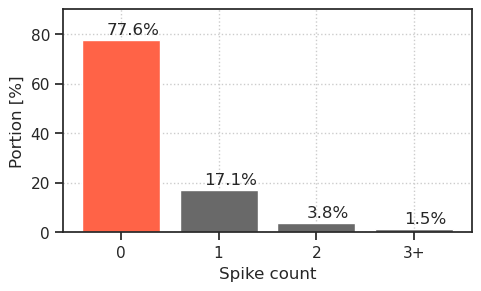

In [11]:
## was: cubic

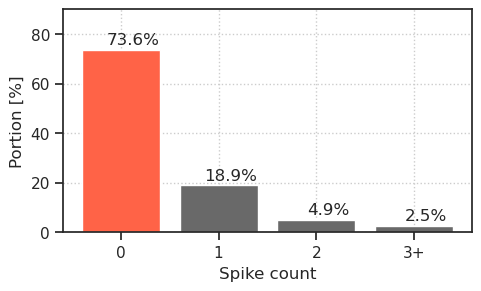

In [10]:
## was: sigmoid

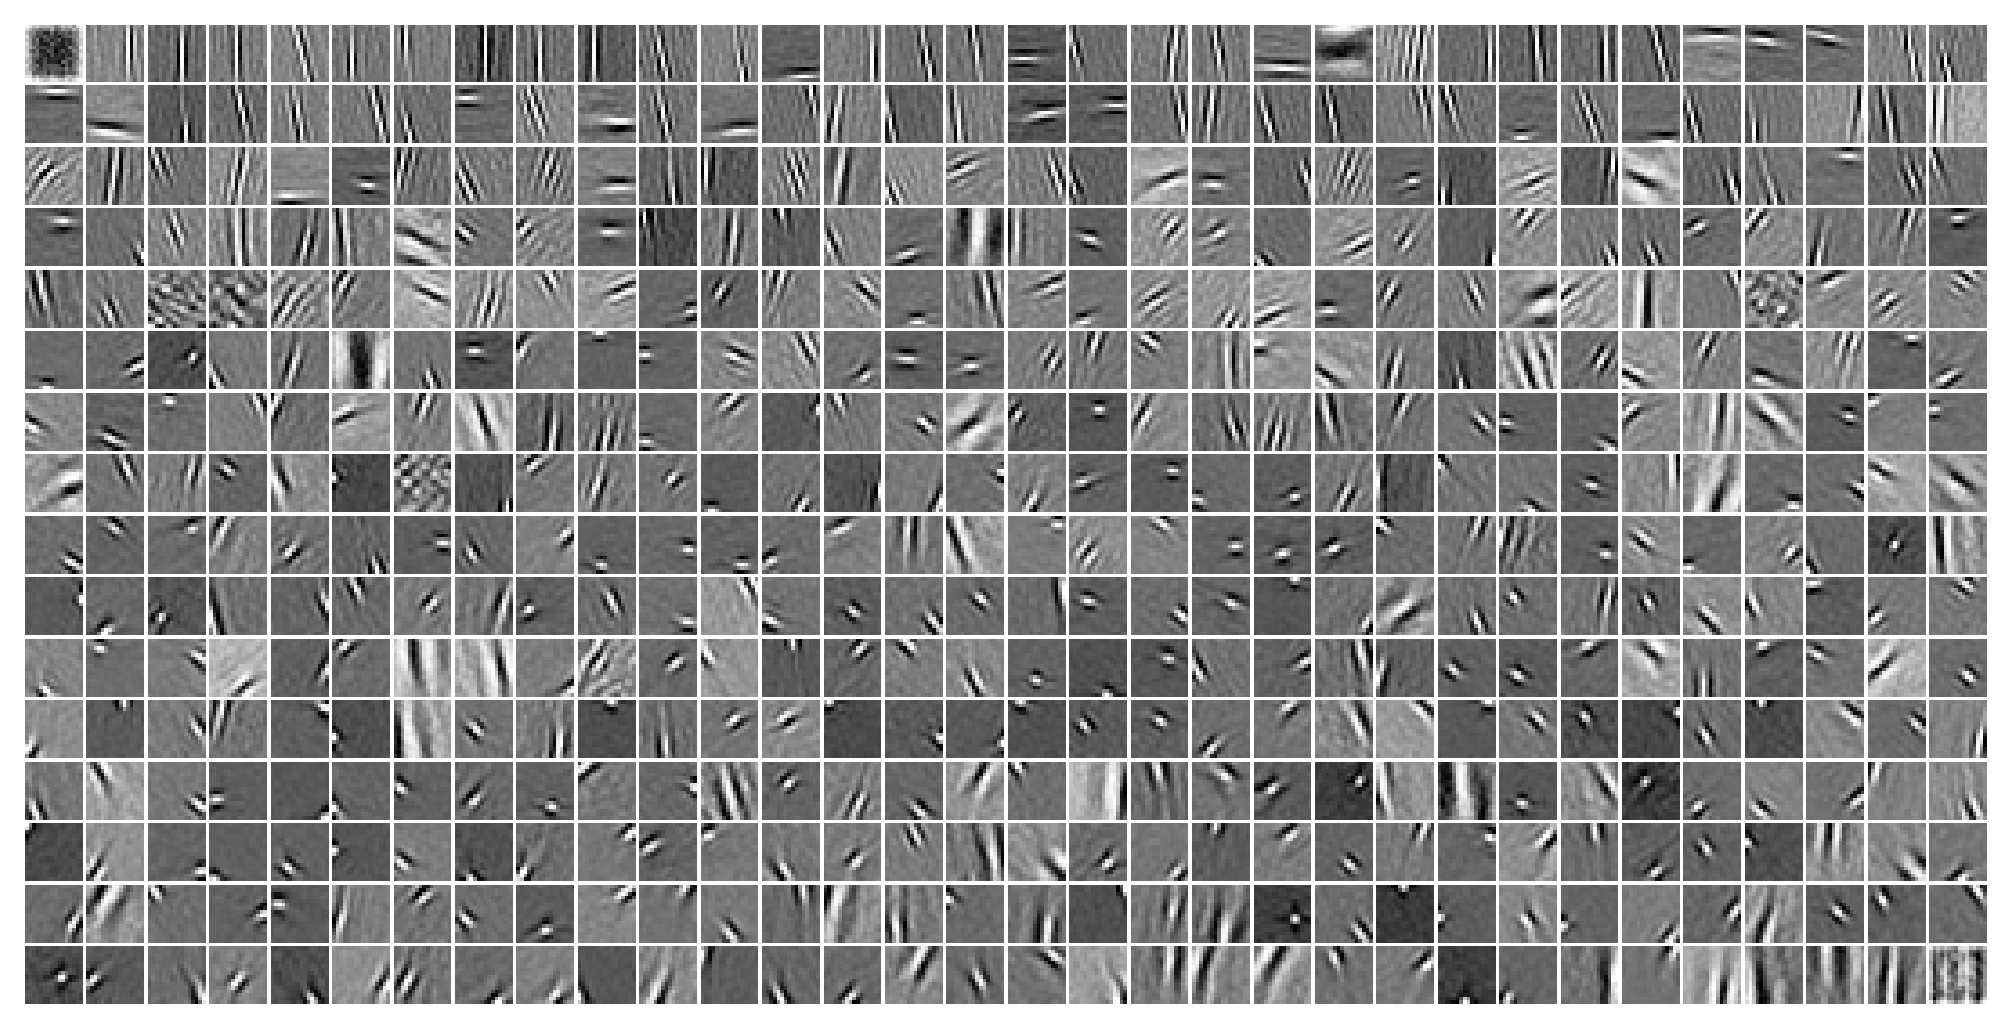

In [16]:
vae.show(dpi=250, order=np.argsort(tonp(vae.log_rate.squeeze())));

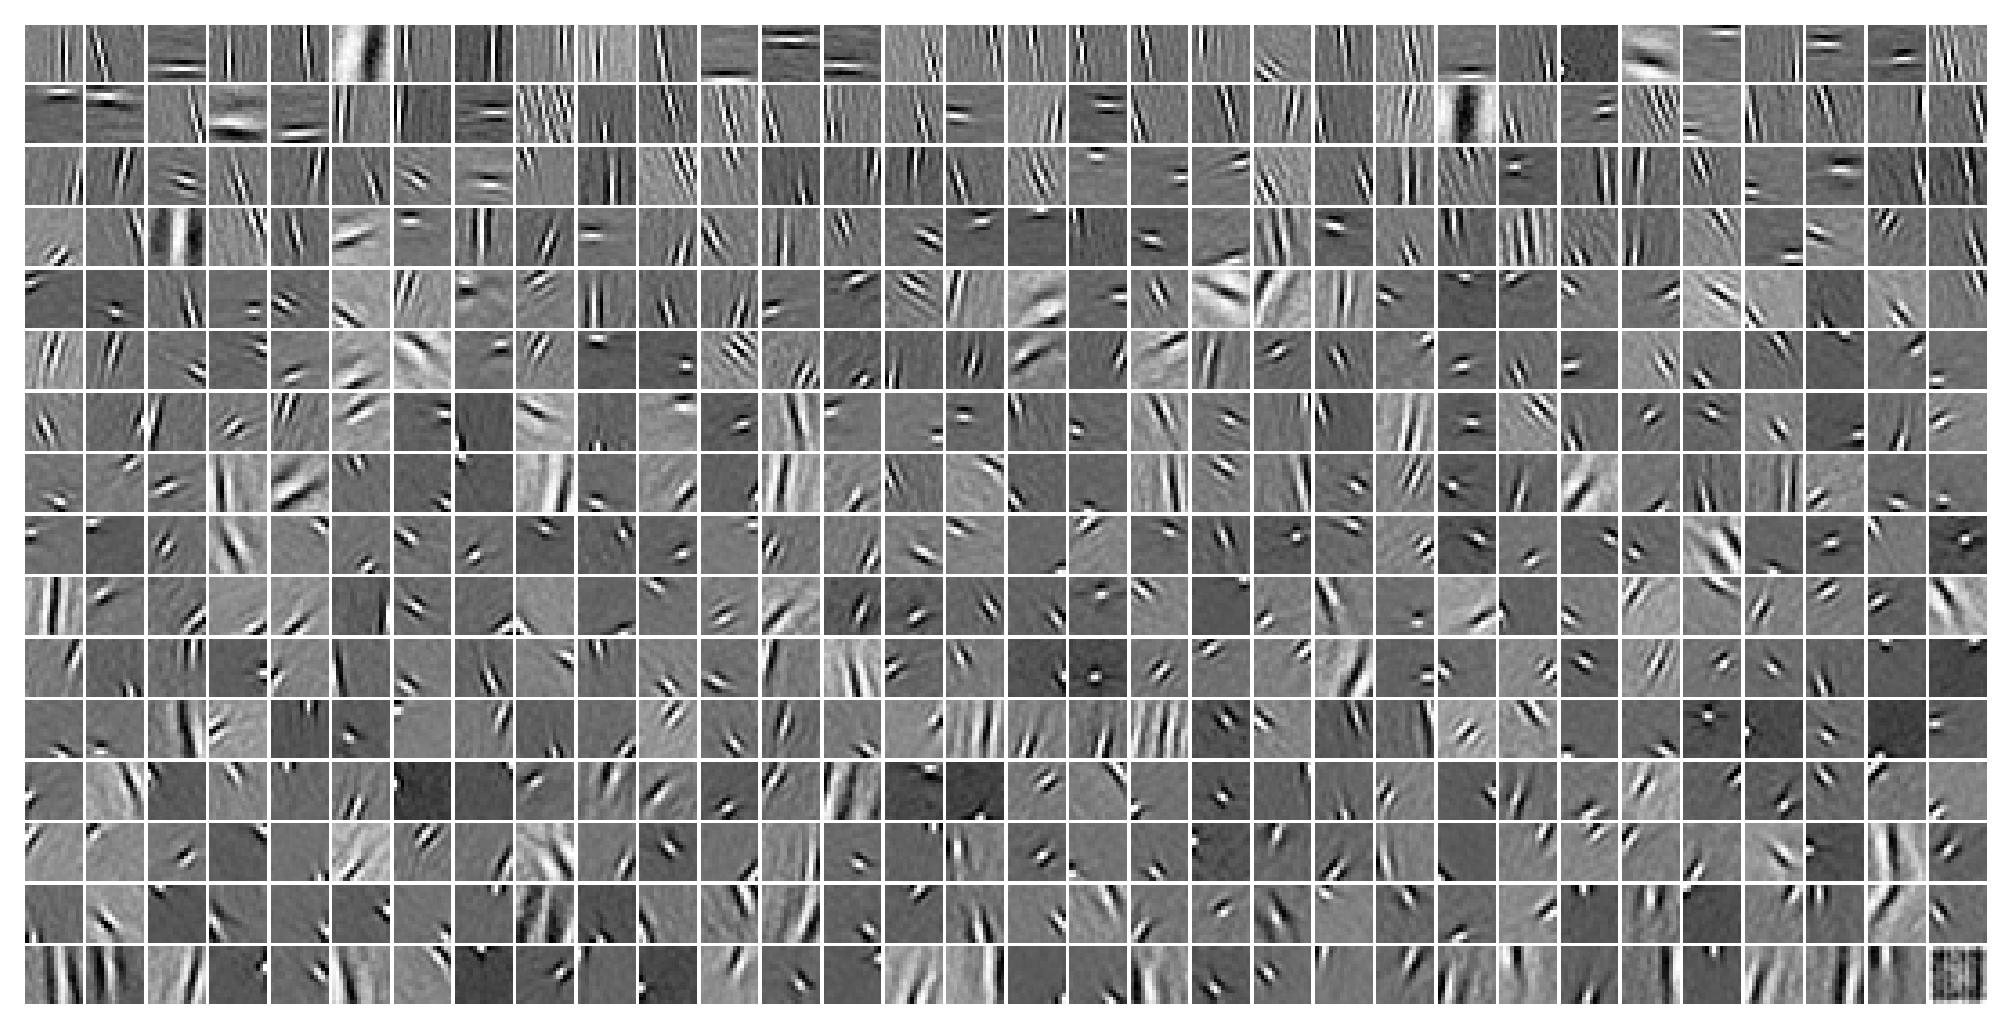

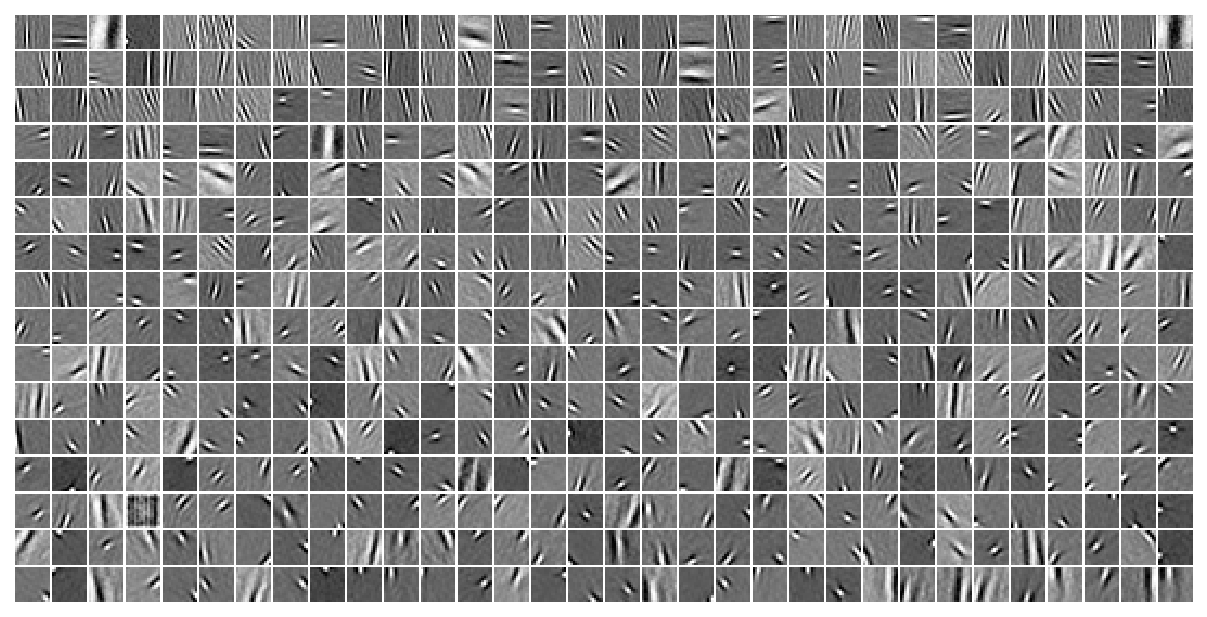

In [13]:
## was: cubic

## Plot some data samples

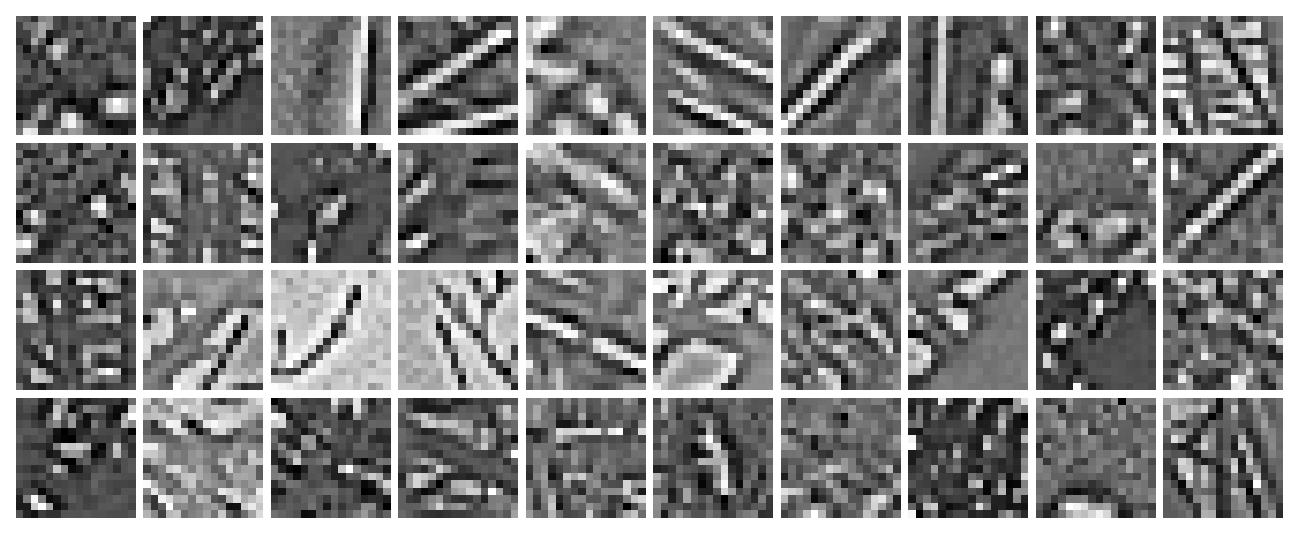

In [24]:
x_vld = tr.dl_vld.dataset.tensors[0]

var = torch.var(x_vld, dim=(1, 2, 3))
sort_ids = np.argsort(tonp(var))[::-1]

x_selected = tonp(x_vld)[sort_ids][:40]


from figures.imgs import plot_weights

_ = plot_weights(x_selected, nrows=4)

## The data that was on Drive

In [26]:
data = np.load(pjoin(add_home('Dropbox/processed.npy')))
data.shape

(128956, 1, 16, 16)

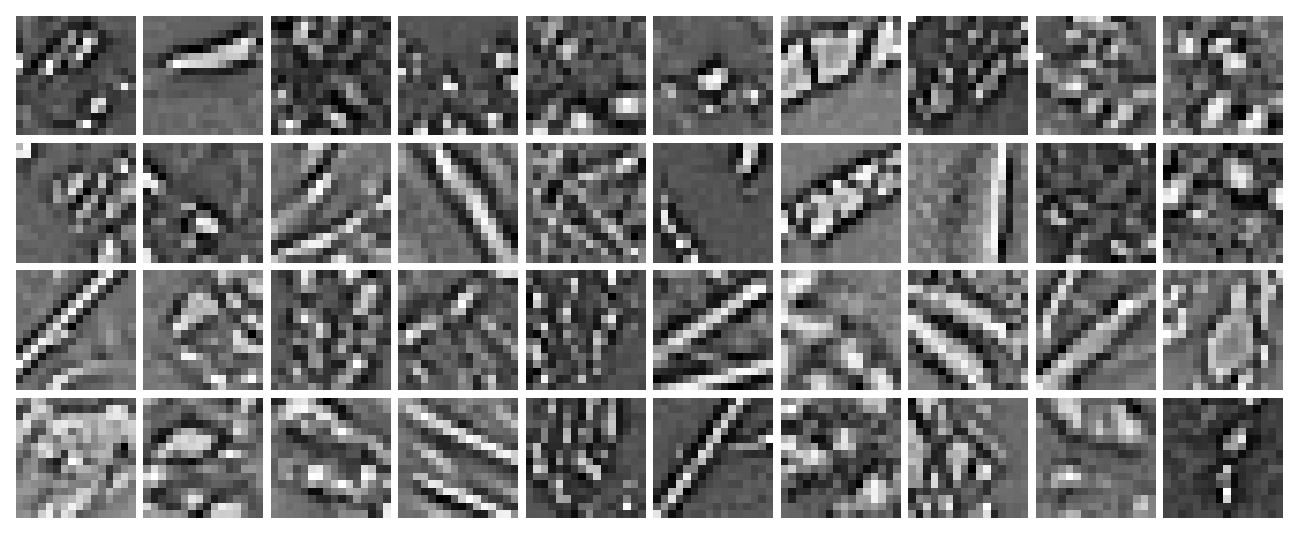

In [29]:
var = np.var(data, axis=(1, 2, 3))
sort_ids = np.argsort(tonp(var))[::-1]

x_selected = data[sort_ids][:40]


from figures.imgs import plot_weights

_ = plot_weights(x_selected, nrows=4)